In [ ]:
# !pip install pandas sqlalchemy pyodbc scikit-learn joblib matplotlib


In [1]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from urllib.parse import quote_plus
from sqlalchemy import create_engine

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Import thư viện thành công")

Import thư viện thành công


In [2]:
SERVER = "localhost,1433"
DATABASE = "weather_db"
USERNAME = "airflow_user"
PASSWORD = "123456"
TABLE_NAME = "weather_summary"

MODEL_DIR = "models"
MODEL_PATH = os.path.join(MODEL_DIR, "weather_prediction_model.pkl")
REPORT_PATH = os.path.join(MODEL_DIR, "weather_model_report.txt")

os.makedirs(MODEL_DIR, exist_ok=True)

connection_string = (
    "DRIVER={ODBC Driver 18 for SQL Server};"
    f"SERVER={SERVER};"
    f"DATABASE={DATABASE};"
    f"UID={USERNAME};"
    f"PWD={PASSWORD};"
    "TrustServerCertificate=yes;"
)

params = quote_plus(connection_string)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

print("Đã cấu hình kết nối SQL Server")

Đã cấu hình kết nối SQL Server


In [3]:
query = f"""
SELECT
    country_name,
    country_code,
    element,
    year,
    month,
    avg_value,
    max_value,
    min_value,
    record_count
FROM {TABLE_NAME}
WHERE avg_value IS NOT NULL
"""

df = pd.read_sql(query, engine)

print("Số dòng dữ liệu:", len(df))
df.head()

Số dòng dữ liệu: 405297


,country_name,country_code,element,year,month,avg_value,max_value,min_value,record_count
0,Northern Mariana Islands [United States],CQ,PRCP,1969,2,12.928571,86.0,0.0,28
1,Czech Republic,EZ,TMAX,1969,2,-0.325000,9.5,-11.2,56
2,Czech Republic,EZ,TMIN,1969,2,-5.267857,3.1,-14.4,56
3,Czech Republic,EZ,PRCP,1969,2,8.285714,137.0,0.0,28
4,New Zealand,NZ,PRCP,1969,2,43.454545,460.0,0.0,33


In [4]:
print("Thông tin dữ liệu:")
print(df.info())

print("\nSố giá trị thiếu:")
print(df.isnull().sum())

print("\nCác chỉ số khí hậu:")
print(df["element"].value_counts())

print("\nKhoảng năm:")
print(df["year"].min(), "-", df["year"].max())

print("\nSố quốc gia:")
print(df["country_name"].nunique())

Thông tin dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 405297 entries, 0 to 405296
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   country_name  405297 non-null  str    
 1   country_code  405297 non-null  str    
 2   element       405297 non-null  str    
 3   year          405297 non-null  int64  
 4   month         405297 non-null  int64  
 5   avg_value     405297 non-null  float64
 6   max_value     405297 non-null  float64
 7   min_value     405297 non-null  float64
 8   record_count  405297 non-null  int64  
dtypes: float64(3), int64(3), str(3)
memory usage: 34.5 MB
None

Số giá trị thiếu:
country_name    0
country_code    0
element         0
year            0
month           0
avg_value       0
max_value       0
min_value       0
record_count    0
dtype: int64

Các chỉ số khí hậu:
element
TMIN    136386
TMAX    136228
PRCP    132683
Name: count, dtype: int64

Khoảng năm:
1951 - 2026

Số quốc gia:
2

In [5]:
df = df.dropna(subset=[
    "country_name",
    "country_code",
    "element",
    "year",
    "month",
    "avg_value"
])

df["year"] = df["year"].astype(int)
df["month"] = df["month"].astype(int)

df["avg_value"] = pd.to_numeric(df["avg_value"], errors="coerce")
df["max_value"] = pd.to_numeric(df["max_value"], errors="coerce")
df["min_value"] = pd.to_numeric(df["min_value"], errors="coerce")
df["record_count"] = pd.to_numeric(df["record_count"], errors="coerce")

df = df.dropna()

print("Số dòng sau xử lý:", len(df))
df.head()

Số dòng sau xử lý: 405297


,country_name,country_code,element,year,month,avg_value,max_value,min_value,record_count
0,Northern Mariana Islands [United States],CQ,PRCP,1969,2,12.928571,86.0,0.0,28
1,Czech Republic,EZ,TMAX,1969,2,-0.325000,9.5,-11.2,56
2,Czech Republic,EZ,TMIN,1969,2,-5.267857,3.1,-14.4,56
3,Czech Republic,EZ,PRCP,1969,2,8.285714,137.0,0.0,28
4,New Zealand,NZ,PRCP,1969,2,43.454545,460.0,0.0,33


In [6]:
X = df[[
    "country_name",
    "country_code",
    "element",
    "year",
    "month",
    "max_value",
    "min_value",
    "record_count"
]]

y = df["avg_value"]

categorical_features = [
    "country_name",
    "country_code",
    "element"
]

numeric_features = [
    "year",
    "month",
    "max_value",
    "min_value",
    "record_count"
]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (405297, 8)
y shape: (405297,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 324237
Test size: 81060


In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

print("Đã tạo pipeline model")

Đã tạo pipeline model


In [9]:
print("Đang train model Random Forest...")
pipeline.fit(X_train, y_train)
print("Train model hoàn tất")

Đang train model Random Forest...
Train model hoàn tất


In [10]:
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Kết quả đánh giá mô hình:")
print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

Kết quả đánh giá mô hình:
MAE: 4.2688855053115615
MSE: 200.13222722984077
R2 Score: 0.9223527602826056


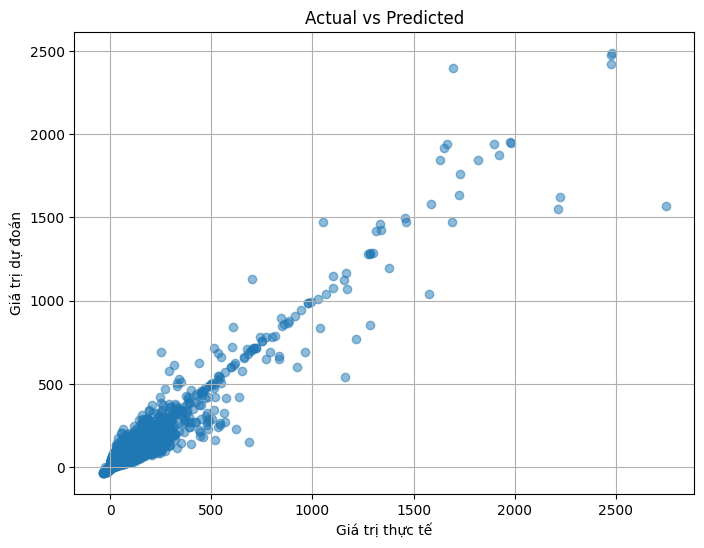

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Giá trị thực tế")
plt.ylabel("Giá trị dự đoán")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()

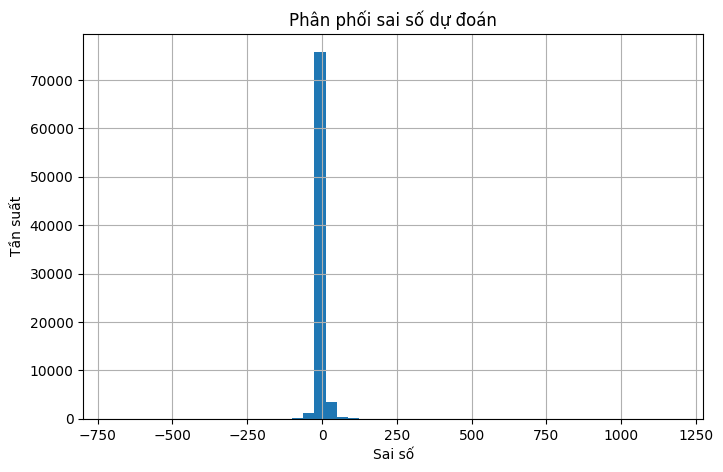

In [12]:
errors = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.hist(errors, bins=50)
plt.xlabel("Sai số")
plt.ylabel("Tần suất")
plt.title("Phân phối sai số dự đoán")
plt.grid(True)
plt.show()

In [13]:
joblib.dump(pipeline, MODEL_PATH)

with open(REPORT_PATH, "w", encoding="utf-8") as f:
    f.write("WEATHER PREDICTION MODEL REPORT\n")
    f.write("===============================\n")
    f.write(f"Total rows: {len(df)}\n")
    f.write(f"Train rows: {len(X_train)}\n")
    f.write(f"Test rows: {len(X_test)}\n")
    f.write("Model: RandomForestRegressor\n")
    f.write(f"MAE: {mae}\n")
    f.write(f"MSE: {mse}\n")
    f.write(f"R2 Score: {r2}\n")

print("Đã lưu model:", MODEL_PATH)
print("Đã lưu report:", REPORT_PATH)

Đã lưu model: models\weather_prediction_model.pkl
Đã lưu report: models\weather_model_report.txt


In [14]:
sample = X_test.iloc[[0]]
actual = y_test.iloc[0]
predicted = pipeline.predict(sample)[0]

print("Input mẫu:")
display(sample)

print("Giá trị thực tế:", actual)
print("Giá trị dự đoán:", predicted)

Input mẫu:


,country_name,country_code,element,year,month,max_value,min_value,record_count
116103,Bulgaria,BU,TMIN,2017,3,8.8,-3.4,74


Giá trị thực tế: 3.554054054054054
Giá trị dự đoán: 2.806380327600879


In [15]:
def predict_weather(country_name, country_code, element, year, month, max_value, min_value, record_count):
    input_df = pd.DataFrame([{
        "country_name": country_name,
        "country_code": country_code,
        "element": element,
        "year": int(year),
        "month": int(month),
        "max_value": float(max_value),
        "min_value": float(min_value),
        "record_count": float(record_count)
    }])

    prediction = pipeline.predict(input_df)[0]
    return prediction

# Ví dụ test
result = predict_weather(
    country_name="Vietnam",
    country_code="VM",
    element="TMAX",
    year=2026,
    month=1,
    max_value=35,
    min_value=20,
    record_count=100
)

print("Kết quả dự đoán:", result)

Kết quả dự đoán: 28.749422015753122
